In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.datasets import Food101
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random
from collections import Counter

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

### load dataset

In [ ]:
train_data = Food101(root="data", split="train", download=True, transform=train_transform)
test_data = Food101(root="data", split="test", download=True, transform=test_transform)

100%|██████████| 5.00G/5.00G [03:34<00:00, 23.3MB/s]


### Dataloaders

In [ ]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2)

- Converts dataset into batches
- shuffle=True helps training generalization

## 1. Exploratory Data Analysis (EDA)

In [ ]:
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))
print("Classes:", len(train_data.classes))

labels = [label for _, label in train_data]
print("Top classes:", Counter(labels).most_common(5))

Train samples: 75750
Test samples: 25250
Classes: 101
Top classes: [(23, 750), (54, 750), (85, 750), (86, 750), (77, 750)]


### Show random images per class

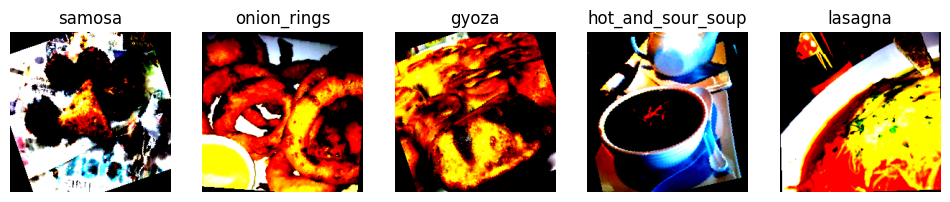

In [ ]:
def show_samples(dataset, n=5):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]

        # unnormalize for display
        img = img.permute(1,2,0)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(dataset.classes[label])
        plt.axis("off")

show_samples(train_data)

### Class distribution check

In [ ]:
from collections import Counter

labels = [label for _, label in train_data]
counter = Counter(labels)

print("Most common classes:", counter.most_common(10))

Most common classes: [(23, 750), (54, 750), (85, 750), (86, 750), (77, 750), (92, 750), (73, 750), (4, 750), (48, 750), (39, 750)]


## 2. HEAVY DATA AUGMENTATION

- Augmentation prevents overfitting
- Makes model robust to real-world images

### Augmentation pipeline

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # zoom
    transforms.RandomHorizontalFlip(),                    # flip
    transforms.RandomRotation(30),                        # rotation
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),                                                    # brightness/color
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

### Reload dataset with augmentation

In [ ]:
train_data = Food101(root="data", split="train", download=True, transform=train_transform)
test_data = Food101(root="data", split="test", download=True, transform=test_transform)


### data loaders

- shuffle only training set
- batch size 64 = good balance speed/memory

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=64)

## 2. Load Pretrained Model (ResNet50)

- We use transfer learning
- Only last layer is trained
- Faster + better accuracy

In [ ]:
model = torchvision.models.resnet50(pretrained=True)

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

# replace classifier
model.fc = nn.Linear(model.fc.in_features, 101)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


## 3. Loss + Optimizer

- CrossEntropy = classification loss
- Only training final layer parameters

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
# unfreeze last block + classifier
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

## 4.training loop

In [ ]:
print(len(train_loader))

1184


In [ ]:
print("Number of batches:", len(train_loader))

Number of batches: 1184


In [ ]:
images, labels = next(iter(train_loader))
print("Loaded one batch successfully")

Loaded one batch successfully


In [ ]:
print("Starting training...")

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        #  PRINT EVERY 20 BATCHES
        if i % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Batch [{i}/{len(train_loader)}] Loss: {loss.item():.4f}")

    print(f" Epoch {epoch+1} finished | Total Loss: {total_loss:.4f}")

Starting training...
Epoch [1/3] Batch [0/1184] Loss: 4.6846
Epoch [1/3] Batch [20/1184] Loss: 4.4475
Epoch [1/3] Batch [40/1184] Loss: 3.9850
Epoch [1/3] Batch [60/1184] Loss: 3.7006
Epoch [1/3] Batch [80/1184] Loss: 3.5939
Epoch [1/3] Batch [100/1184] Loss: 3.0236
Epoch [1/3] Batch [120/1184] Loss: 2.9053
Epoch [1/3] Batch [140/1184] Loss: 2.8095
Epoch [1/3] Batch [160/1184] Loss: 2.2911
Epoch [1/3] Batch [180/1184] Loss: 2.3073
Epoch [1/3] Batch [200/1184] Loss: 2.4039
Epoch [1/3] Batch [220/1184] Loss: 2.5485
Epoch [1/3] Batch [240/1184] Loss: 2.2201
Epoch [1/3] Batch [260/1184] Loss: 2.2510
Epoch [1/3] Batch [280/1184] Loss: 1.9181
Epoch [1/3] Batch [300/1184] Loss: 2.2194
Epoch [1/3] Batch [320/1184] Loss: 1.9976
Epoch [1/3] Batch [340/1184] Loss: 1.9629
Epoch [1/3] Batch [360/1184] Loss: 2.3156
Epoch [1/3] Batch [380/1184] Loss: 1.9510
Epoch [1/3] Batch [400/1184] Loss: 2.1389
Epoch [1/3] Batch [420/1184] Loss: 1.7672
Epoch [1/3] Batch [440/1184] Loss: 1.7125
Epoch [1/3] Batch [

## 5.evaluation

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 76.32%


## 6. Misclassification Analysis

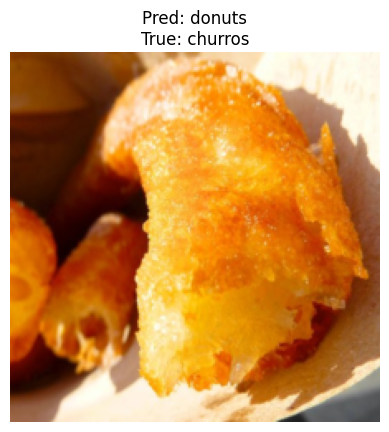

In [ ]:
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

for i in range(5):
    if preds[i] != labels[i]:
        img = images[i].cpu().permute(1,2,0)

        plt.imshow(img)
        plt.title(f"Pred: {train_data.classes[preds[i]]}\nTrue: {train_data.classes[labels[i]]}")
        plt.axis("off")
        plt.show()

In [ ]:
print("Starting training...")

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        #  PRINT EVERY 20 BATCHES
        if i % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Batch [{i}/{len(train_loader)}] Loss: {loss.item():.4f}")

    print(f" Epoch {epoch+1} finished | Total Loss: {total_loss:.4f}")

Starting training...
Epoch [1/5] Batch [0/1184] Loss: 0.5839
Epoch [1/5] Batch [20/1184] Loss: 0.7216
Epoch [1/5] Batch [40/1184] Loss: 0.8170
Epoch [1/5] Batch [60/1184] Loss: 0.8925
Epoch [1/5] Batch [80/1184] Loss: 0.5645
Epoch [1/5] Batch [100/1184] Loss: 0.5401
Epoch [1/5] Batch [120/1184] Loss: 1.0554
Epoch [1/5] Batch [140/1184] Loss: 0.6501
Epoch [1/5] Batch [160/1184] Loss: 0.9714
Epoch [1/5] Batch [180/1184] Loss: 0.7595
Epoch [1/5] Batch [200/1184] Loss: 0.9311
Epoch [1/5] Batch [220/1184] Loss: 1.0320
Epoch [1/5] Batch [240/1184] Loss: 0.6464
Epoch [1/5] Batch [260/1184] Loss: 0.8186
Epoch [1/5] Batch [280/1184] Loss: 0.9625
Epoch [1/5] Batch [300/1184] Loss: 0.6916
Epoch [1/5] Batch [320/1184] Loss: 0.8165
Epoch [1/5] Batch [340/1184] Loss: 1.0480
Epoch [1/5] Batch [360/1184] Loss: 0.6746
Epoch [1/5] Batch [380/1184] Loss: 0.7428
Epoch [1/5] Batch [400/1184] Loss: 0.8266
Epoch [1/5] Batch [420/1184] Loss: 1.0523
Epoch [1/5] Batch [440/1184] Loss: 0.3377
Epoch [1/5] Batch [

## Evaluation

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 79.31%


## missclassification

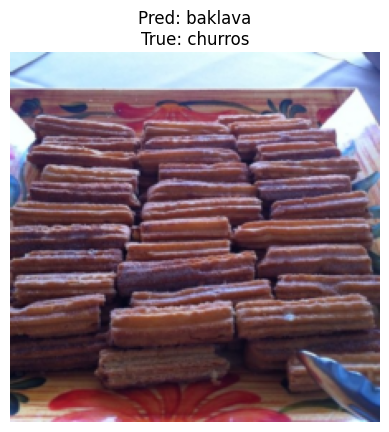

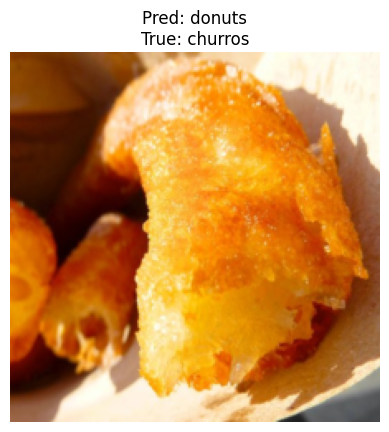

In [ ]:
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

for i in range(5):
    if preds[i] != labels[i]:
        img = images[i].cpu().permute(1,2,0)

        plt.imshow(img)
        plt.title(f"Pred: {train_data.classes[preds[i]]}\nTrue: {train_data.classes[labels[i]]}")
        plt.axis("off")
        plt.show()